### 第二次作業：常態分配的平均數 $\mu$ 與標準差 $\sigma$ 的最大概似估計實驗


姓名：陳維萱</font>

學號：411180015</font>

作品目標：令 $x_1$, $x_2$, ..., $x_N$ 為 N 個來自常態分配 N($\mu$, $\sigma^{2}$ ) 的獨立樣本，進行最大概似估計(MLE)實驗。
- 計算聯合概似函數 L($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)或其對數形式 logL($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)，並通過最大化對數概似函數來找到 $\mu$, $\sigma$ 的最大似然估計值。
- 聯合概似函數 L($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)和其為了優化計算的對數形式 logL($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)繪製出來的圖形將有何差別，在程式的運行中使用對數形式計算是否將更快速。
- 觀察單變量 $\mu$、 $\sigma$ ，各固定其一變數，改變另一變數的狀況下，函數圖型中將有何變化。
- 樣本數多寡是否影響聯合概似函數的計算。
- 觀察不同種類雙變量的聯合概似函數圖形樣態（contour plot, mesh plot, heat map）。
- 用迴圈重複執行生成樣本動作M次，並繪製成折線圖，觀察 $\mu$、 $\sigma$ 在不同樣本數下重複生成M次將與實際值差距多少及呈現何種變化。


<hr>
<font color=#EF9520> （一）單變量聯合概似函數線圖觀察</font>

1. 固定 $\sigma$ = 1，$\mu$ 未知，繪製聯合概似函數 L($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)，並在最大值處標示一紅色虛線。
2. 固定 $\mu$ = 1，$\sigma$ 未知，繪製聯合概似函數 L($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)，並在最大值處標示一紅色虛線。
<hr>

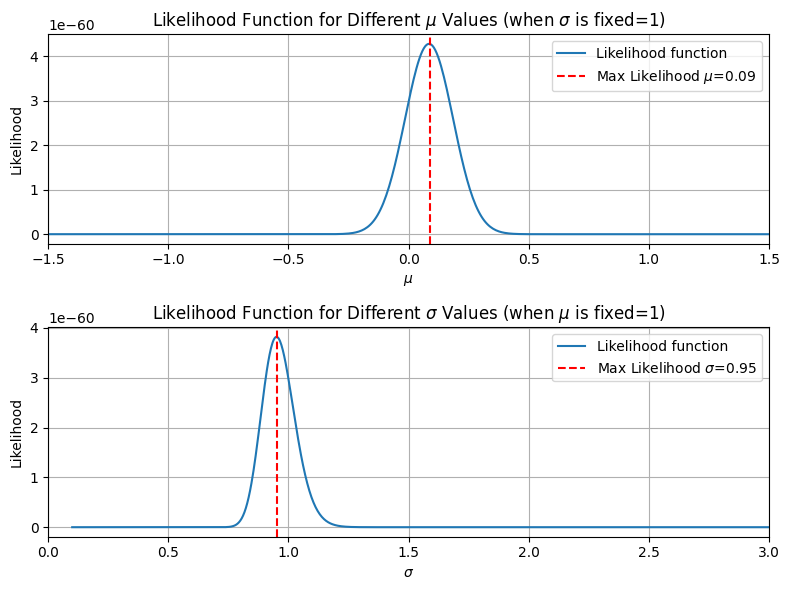

In [13]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
N = 100
mu_true = 0
sigma_true = 1
samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)

# 定義聯合概似函數（針對均值）
def likelihood_mu(mu, samples, sigma):
    return np.prod(stats.norm.pdf(samples, loc=mu, scale=sigma))

# 定義聯合概似函數（針對標準差）
def likelihood_sigma(sigma, samples, mu):
    if sigma <= 0:  # 確保標準差為正
        return 0
    return np.prod(stats.norm.pdf(samples, loc=mu, scale=sigma))

# 計算不同均值下的聯合概似函數值
mu_range = np.linspace(-3, 3, 1000)
likelihood_values_mu = np.array([likelihood_mu(mu, samples, sigma_true) for mu in mu_range])

# 計算不同標準差下的聯合概似函數值
sigma_range = np.linspace(0.1, 3, 1000)
likelihood_values_sigma = np.array([likelihood_sigma(sigma, samples, mu_true) for sigma in sigma_range])

# 找到最大概似數的位置
max_likelihood_mu = mu_range[np.argmax(likelihood_values_mu)]
max_likelihood_sigma = sigma_range[np.argmax(likelihood_values_sigma)]

# 繪製聯合概似函數圖形
fig, axs = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})

# 繪製針對均值的聯合概似函數圖形
axs[0].plot(mu_range, likelihood_values_mu, label='Likelihood function')
axs[0].axvline(max_likelihood_mu, color='red', linestyle='--', label=f'Max Likelihood $\\mu$={max_likelihood_mu:.2f}')
axs[0].set_title(r'Likelihood Function for Different $\mu$ Values (when $\sigma$ is fixed=1)')
axs[0].set_xlabel(r'$\mu$')
axs[0].set_xlim(-1.5, 1.5)
axs[0].set_ylabel('Likelihood')
axs[0].grid(True)
axs[0].legend()

# 繪製針對標準差的聯合概似函數圖形
axs[1].plot(sigma_range, likelihood_values_sigma, label='Likelihood function')
axs[1].axvline(max_likelihood_sigma, color='red', linestyle='--', label=f'Max Likelihood $\\sigma$={max_likelihood_sigma:.2f}')
axs[1].set_title(r'Likelihood Function for Different $\sigma$ Values (when $\mu$ is fixed=1)')
axs[1].set_xlabel(r'$\sigma$')
axs[1].set_xlim(0, 3)
axs[1].set_ylabel('Likelihood')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


>##### <font color = '#384772'> __**注意事項與討論**__：</font>
>
>- 當固定 $\sigma$，$\mu$ 未知時（圖一），線圖成中型常態分配；當固定 $\mu$，$\sigma$ 未知時（圖二），線圖成右偏。
>- 每run一次程式，紅色虛線所在處都不一樣，表示每次估計結果都有些微差異。




<hr>
<font color=#EF9520> （二）單變量對數聯合概似函數線圖觀察</font>

1. 固定 $\sigma$ = 1，$\mu$ 未知，繪製對數聯合概似函數logL($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)，並在最大值處標示一紅色虛線。
2. 固定 $\mu$ = 1，$\sigma$ 未知，繪製對數聯合概似函數logL($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)，並在最大值處標示一紅色虛線。
<hr>

Estimated μ: 0.021866598201046538, Estimated σ: 1.091563425821148


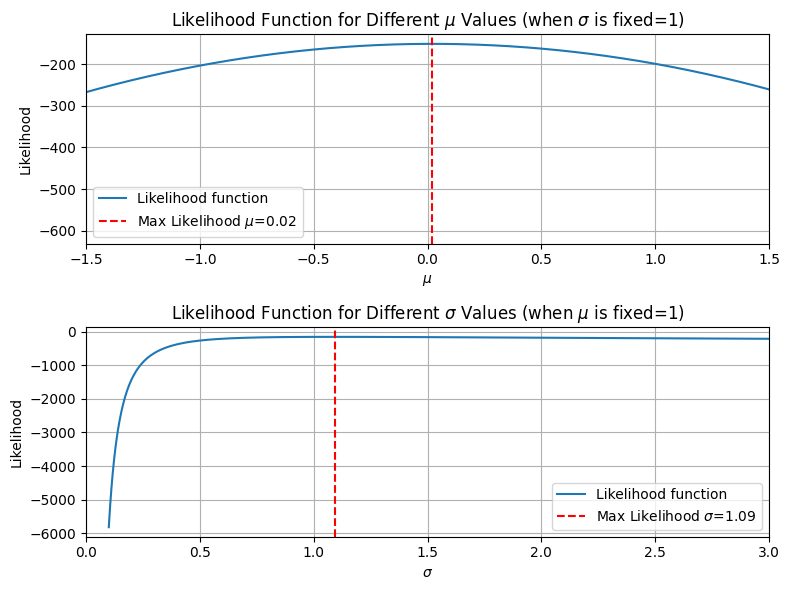

In [20]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 生成樣本數 N
N = 100
mu_true = 0
sigma_true = 1
samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)

# 定義聯合對數概似函數
def log_likelihood(mu, sigma, samples):
    if sigma <= 0:  # 確保標準差為正
        return -np.inf
    pdf_values = stats.norm.pdf(samples, loc=mu, scale=sigma)
    if np.any(pdf_values <= 0):  # 確保 PDF 值為正
        return -np.inf
    return np.sum(np.log(pdf_values))

# 定義負對數概似函數
def neg_log_likelihood(params, samples):
    mu, sigma = params
    return -log_likelihood(mu, sigma, samples)

# 使用 minimize 進行優化，最小化負的對數概似函數
initial_guess = [0, 1]
result = minimize(neg_log_likelihood, initial_guess, args=(samples,))
mu_est, sigma_est = result.x
print(f"Estimated μ: {mu_est}, Estimated σ: {sigma_est}")

# 設定 \mu 和 \sigma 的範圍
mu_range = np.linspace(-3, 3, 1000)
likelihood_values_mu = np.array([log_likelihood(mu, sigma_true, samples) for mu in mu_range])

# 計算不同標準差下的聯合概似函數值
sigma_range = np.linspace(0.1, 3, 1000)
likelihood_values_sigma = np.array([log_likelihood(mu_true, sigma, samples) for sigma in sigma_range])

# 找到最大概似數的位置
max_likelihood_mu = mu_range[np.argmax(likelihood_values_mu)]
max_likelihood_sigma = sigma_range[np.argmax(likelihood_values_sigma)]

# 繪製聯合概似函數圖形
fig, axs = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})

# 繪製針對均值的聯合概似函數圖形
axs[0].plot(mu_range, likelihood_values_mu, label='Likelihood function')
axs[0].axvline(max_likelihood_mu, color='red', linestyle='--', label=f'Max Likelihood $\\mu$={max_likelihood_mu:.2f}')
axs[0].set_title(r'Likelihood Function for Different $\mu$ Values (when $\sigma$ is fixed=1)')
axs[0].set_xlabel(r'$\mu$')
axs[0].set_xlim(-1.5, 1.5)
axs[0].set_ylabel('Likelihood')
axs[0].grid(True)
axs[0].legend()

# 繪製針對標準差的聯合概似函數圖形
axs[1].plot(sigma_range, likelihood_values_sigma, label='Likelihood function')
axs[1].axvline(max_likelihood_sigma, color='red', linestyle='--', label=f'Max Likelihood $\\sigma$={max_likelihood_sigma:.2f}')
axs[1].set_title(r'Likelihood Function for Different $\sigma$ Values (when $\mu$ is fixed=1)')
axs[1].set_xlabel(r'$\sigma$')
axs[1].set_xlim(0, 3)
axs[1].set_ylabel('Likelihood')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

>##### <font color = '#384772'>__**注意事項與討論**__：</font>
>
>- 當固定 $\sigma$，$\mu$ 未知時（圖一），線圖成拋物線，右側快速下降；當固定 $\mu$，$\sigma$ 未知時（圖二），線圖成右側不對稱的型態。
>- 固定 $\sigma$，$\mu$ 未知時（圖一）: $\mu$ 越偏離真實值對數聯合概似函數的值會逐漸下降，代表偏離均值的  $\mu$ 與樣本數據不符。
>- 固定 $\mu$，$\sigma$ 未知時（圖二）:左側趨勢可以看到越小的 $\sigma$（越接近0），對數聯合概似函數急劇下降，是由於非常小的 $\sigma$ 數據幾乎沒有變異性，這與大多數樣本數據的情況不符；而右側趨勢中，越大的 $\sigma$ 對數聯合概似函數卻無劇烈變化，這表示更大的標準差允許數據有更大的變異。
>- 每run一次程式，紅色虛線所在處都不一樣，表示每次估計結果都有些微差異。

<hr>
<font color=#EF9520>（三)不同樣本數變化下對估計值的觀察 </font> 

1. 給定樣本數N=10, 50, 100, 500, 1000, 10000，固定 $\sigma$ = 1，分別繪製六張圖，在 $\mu$ 的最大估計值畫上紅色虛線並觀察六張圖之估計變化。
2. 給定樣本數N=10, 50, 100, 500, 1000, 10000，固定 $\mu$ = 1，分別繪製六張圖，在 $\sigma$ 的最大估計值畫上紅色虛線並觀察六張圖之估計變化。


<hr>

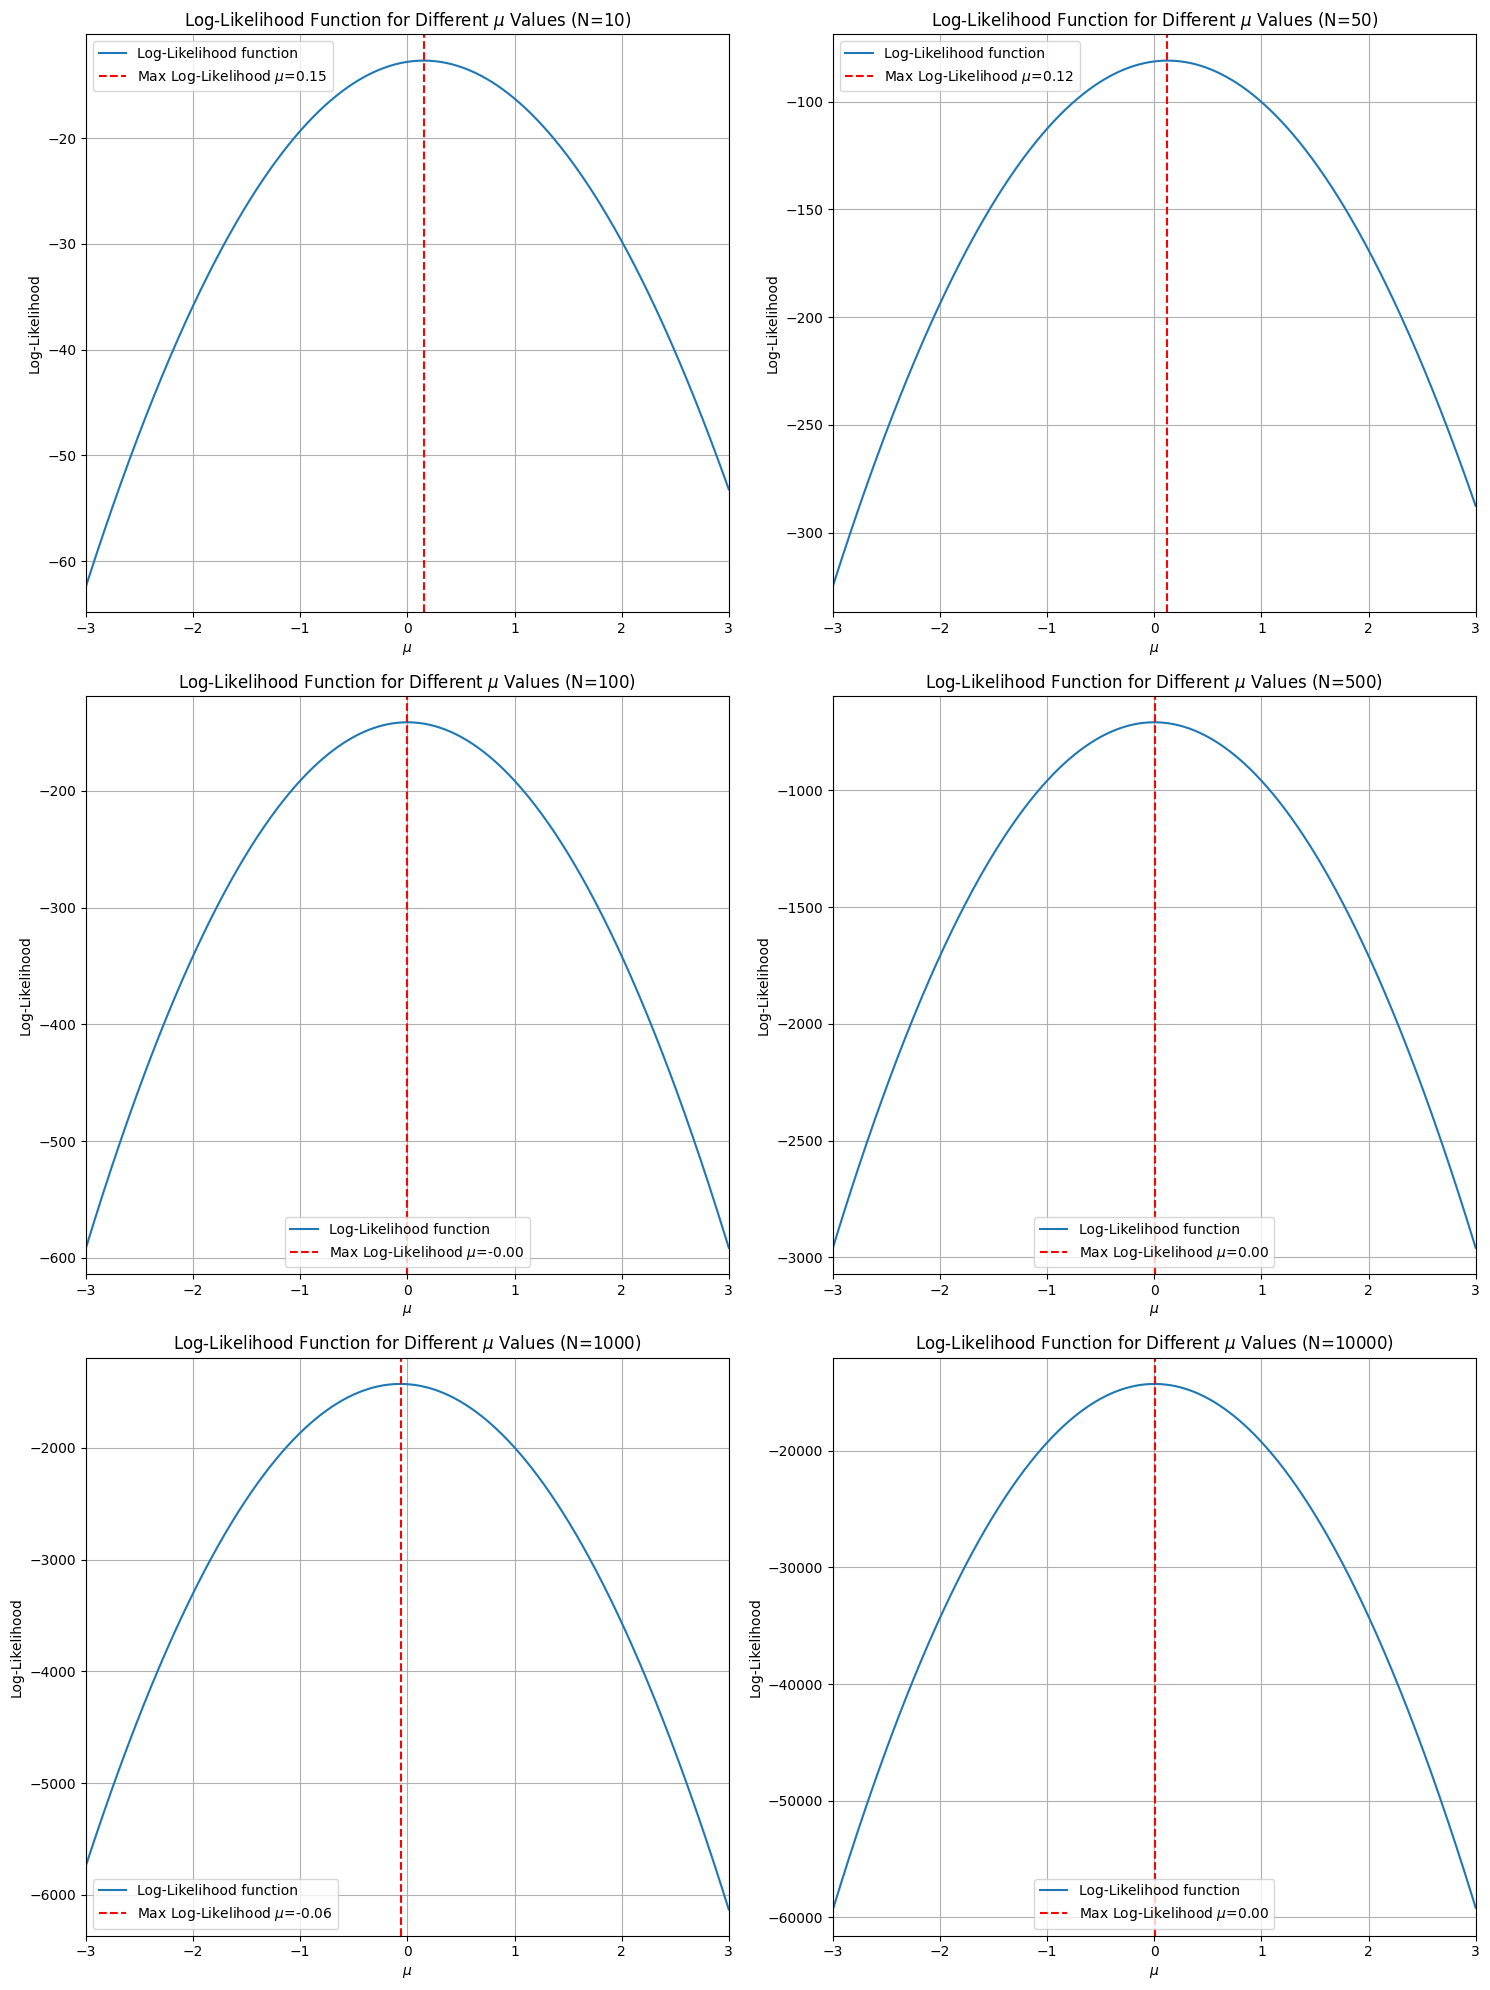

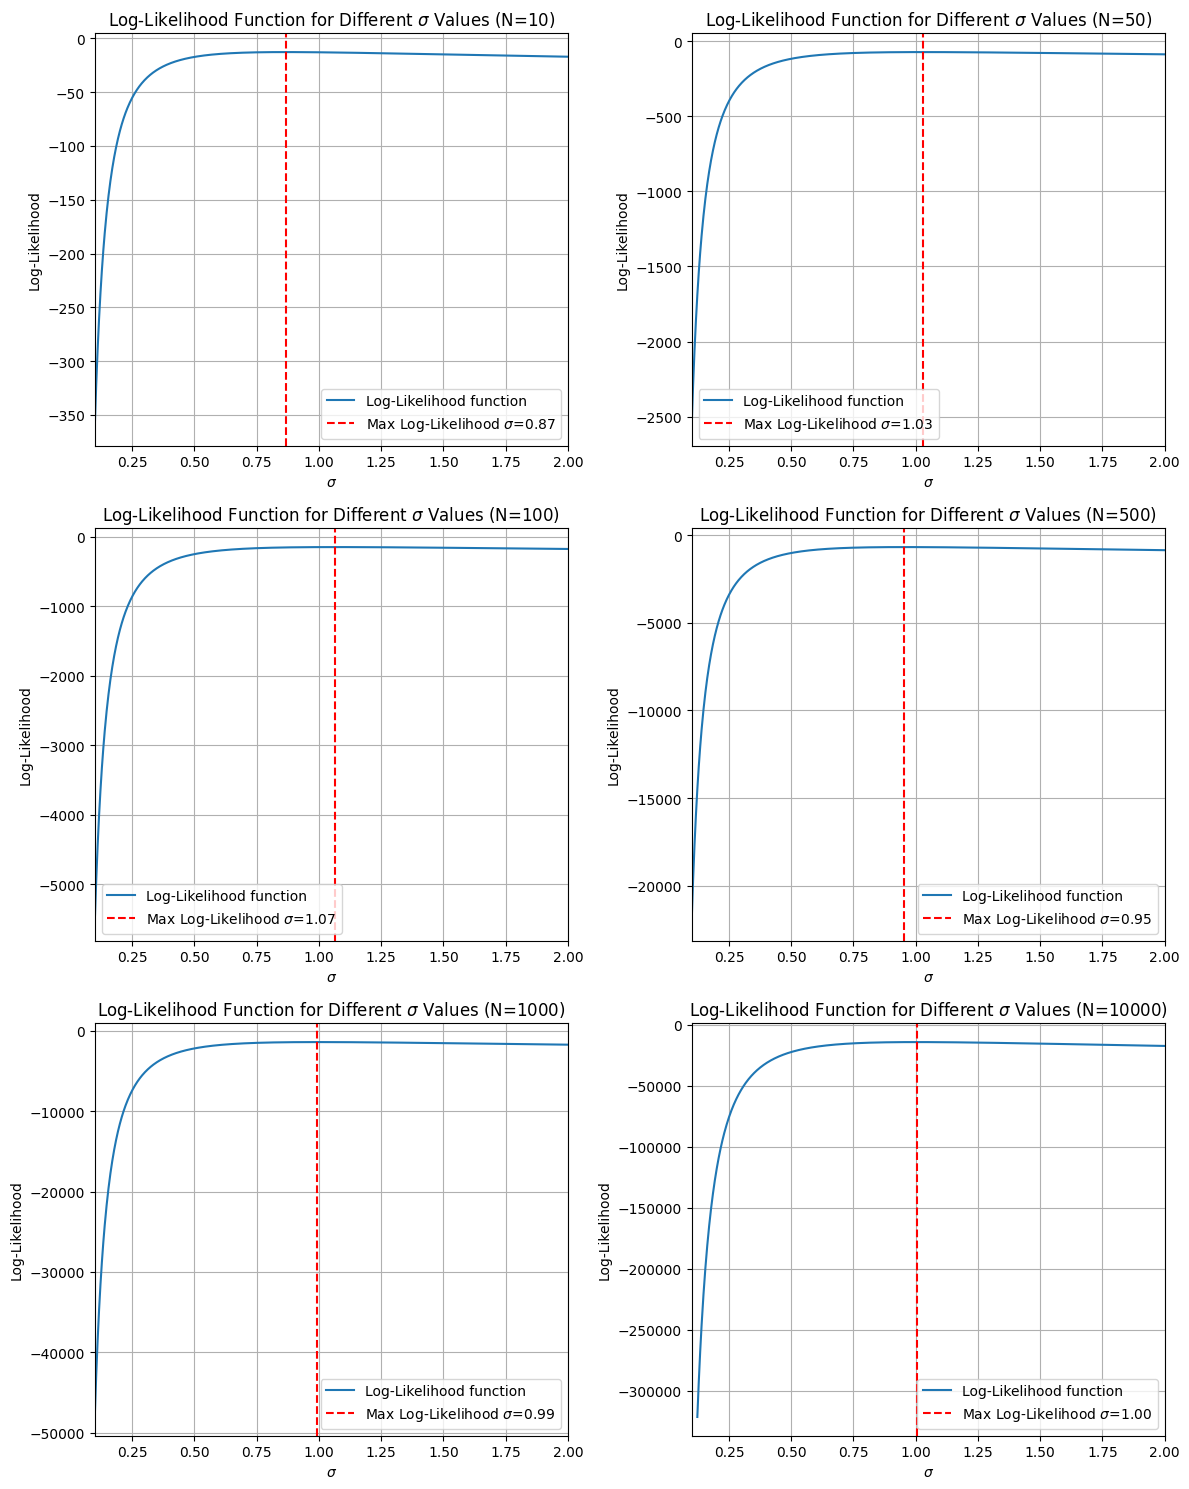

In [49]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 定義聯合對數概似函數
def log_likelihood(mu, sigma, samples):
    if sigma <= 0:  # 確保標準差為正
        return -np.inf
    pdf_values = stats.norm.pdf(samples, loc=mu, scale=sigma)
    if np.any(pdf_values <= 0):  # 確保 PDF 值為正
        return -np.inf
    return np.sum(np.log(pdf_values))

# 設定不同的樣本數
N_values = [10, 50, 100, 500, 1000, 10000]
mu_true = 0
sigma_true = 1

# 繪製六張圖，固定 \(\sigma\) 觀察 \(\mu\)
fig, axs = plt.subplots(3, 2, figsize=(15, 20))

for i, N in enumerate(N_values):
    # 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
    samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
    
    # 計算不同均值下的對數聯合概似函數值
    mu_range = np.linspace(-3, 3, 1000)
    log_likelihood_values = np.array([log_likelihood(mu, sigma_true, samples) for mu in mu_range])
    
    # 找到最大對數聯合概似數的位置
    max_log_likelihood_mu = mu_range[np.argmax(log_likelihood_values)]
    
    # 繪製對數聯合概似函數圖形
    ax = axs[i // 2, i % 2]
    ax.plot(mu_range, log_likelihood_values, label='Log-Likelihood function')
    ax.axvline(max_log_likelihood_mu, color='red', linestyle='--', label=f'Max Log-Likelihood $\\mu$={max_log_likelihood_mu:.2f}')
    ax.set_title(f'Log-Likelihood Function for Different $\\mu$ Values (N={N})')
    ax.set_xlabel(r'$\mu$')
    ax.set_xlim(-3, 3)
    ax.set_ylabel('Log-Likelihood')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# 繪製六張圖，固定 \(\mu\) 觀察 \(\sigma\)
fig, axs = plt.subplots(3, 2, figsize=(12, 15))

for i, N in enumerate(N_values):
    # 生成 N 個來自均值為 0 和標準差為 1 的常態分佈的樣本
    samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
    
    # 計算不同標準差下的對數聯合概似函數值
    sigma_range = np.linspace(0.1, 2, 1000)
    log_likelihood_values = np.array([log_likelihood(mu_true, sigma, samples) for sigma in sigma_range])
    
    # 找到最大對數聯合概似數的位置
    max_log_likelihood_sigma = sigma_range[np.argmax(log_likelihood_values)]
    
    # 繪製對數聯合概似函數圖形
    ax = axs[i // 2, i % 2]
    ax.plot(sigma_range, log_likelihood_values, label='Log-Likelihood function')
    ax.axvline(max_log_likelihood_sigma, color='red', linestyle='--', label=f'Max Log-Likelihood $\\sigma$={max_log_likelihood_sigma:.2f}')
    ax.set_title(f'Log-Likelihood Function for Different $\\sigma$ Values (N={N})')
    ax.set_xlabel(r'$\sigma$')
    ax.set_xlim(0.1, 2)
    ax.set_ylabel('Log-Likelihood')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

>##### <font color = '#384772'> __**注意事項與討論：**__</font>
>
>- 兩張圖有相似結論：樣本數N越大，，估計值越趨近真實值；樣本數N越小，估計值越偏離真實值，函數對 $\mu$, $\sigma$ 的不確定性較大。

<hr>
<font color=#EF9520> （四）繪製對數聯合概似函數之雙變量圖型 </font> 

假設 $\mu$. $\sigma$ 未知，樣本數N＝100, 10000，繪製對數聯合概似函數logL($\mu$, $\sigma$|$x_1$, $x_2$, ..., $x_N$)之：
1. Contour plot
2. Mesh plot
3. Heatmap


<hr>

Estimated μ: 0.06301033033783562, Estimated σ: 1.0678818948462572 for N=100
Log-likelihood min: -476.65167379368665, max: -148.46461373296253 for N=100
Estimated μ: -0.0013495221689396122, Estimated σ: 1.000818866146012 for N=10000
Log-likelihood min: -42344.69880387671, max: -14198.127345428937 for N=10000


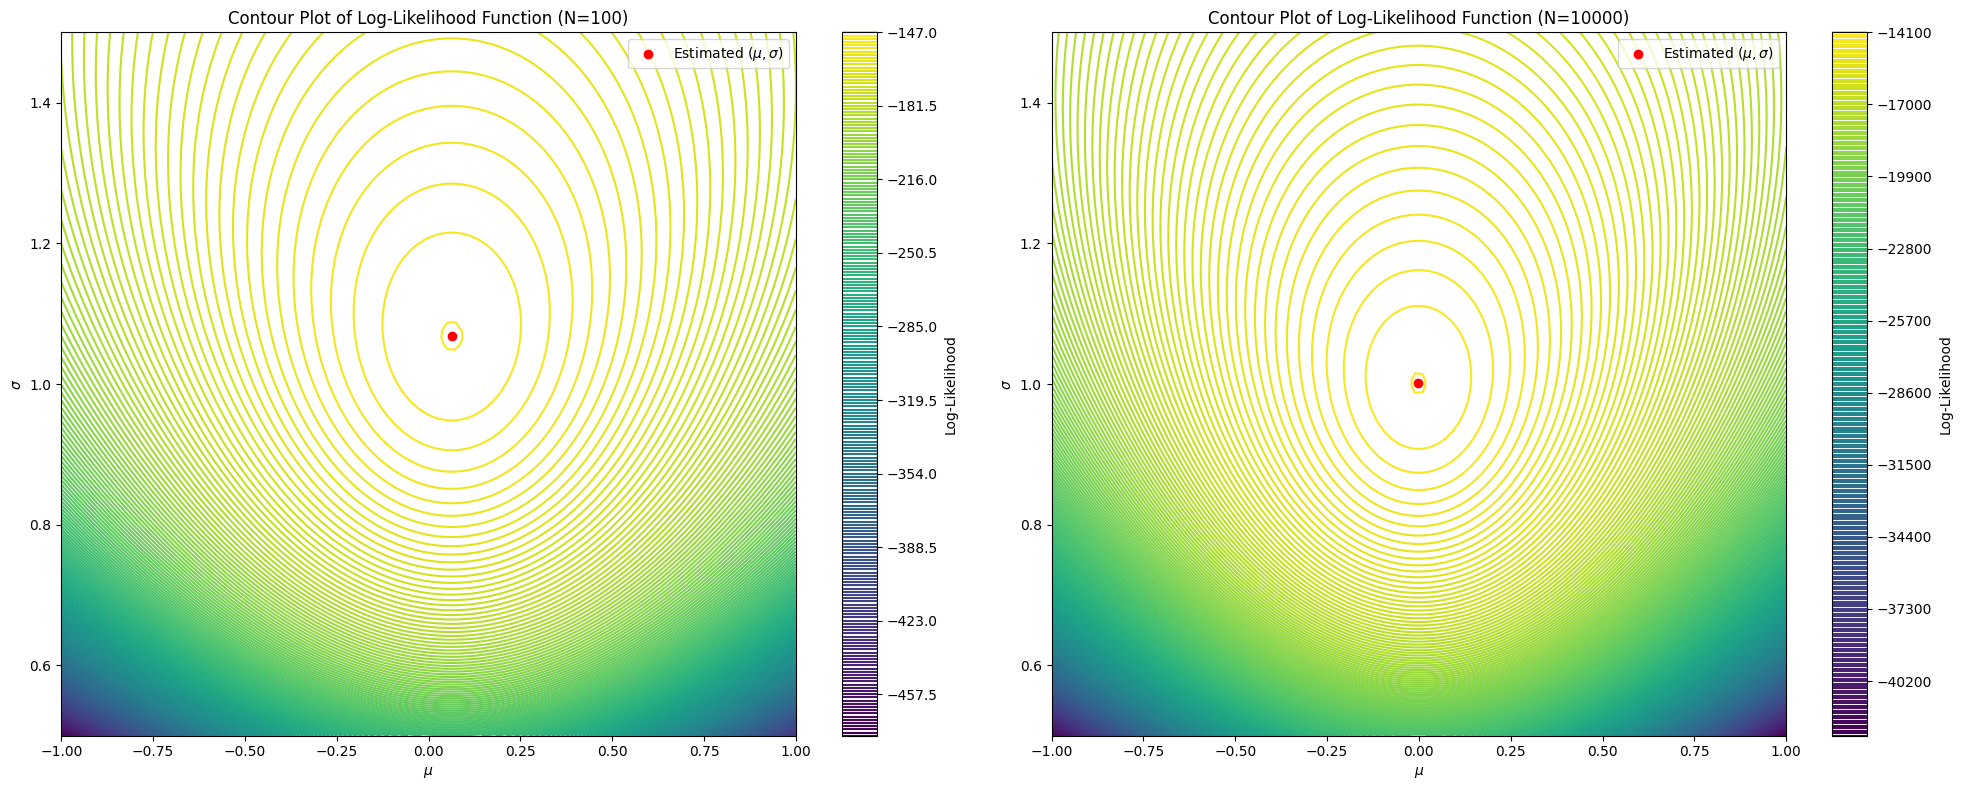

In [23]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 定義聯合對數概似函數
def log_likelihood(mu, sigma, samples):
    if sigma <= 0:  # 確保標準差為正
        return -np.inf
    return np.sum(np.log(stats.norm.pdf(samples, loc=mu, scale=sigma)))

# 定義負對數概似函數
def neg_log_likelihood(params, samples):
    mu, sigma = params
    return -log_likelihood(mu, sigma, samples)

# 設定樣本數
N_values = [100, 10000]
mu_true = 0
sigma_true = 1

# 繪製兩張圖
fig, axs = plt.subplots(1, 2, figsize=(20, 8))  # 調整整張大圖的大小

for i, N in enumerate(N_values):
    # 生成樣本
    samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
    
    # 使用 minimize 進行優化，最小化負的對數聯合概似函數
    initial_guess = [0, 1]
    result = minimize(neg_log_likelihood, initial_guess, args=(samples,))
    mu_est, sigma_est = result.x
    print(f"Estimated μ: {mu_est}, Estimated σ: {sigma_est} for N={N}")

    # 設定 \mu 和 \sigma 的範圍
    mu_range = np.linspace(-1, 1, 100)
    sigma_range = np.linspace(0.5, 1.5, 100)

    # 計算聯合對數概似函數值
    log_likelihood_values = np.zeros((len(sigma_range), len(mu_range)))
    for j, sigma in enumerate(sigma_range):
        for k, mu in enumerate(mu_range):
            log_likelihood_values[j, k] = log_likelihood(mu, sigma, samples)

    # 檢查數值範圍
    print(f"Log-likelihood min: {log_likelihood_values.min()}, max: {log_likelihood_values.max()} for N={N}")

    # 繪製等高線圖
    X, Y = np.meshgrid(mu_range, sigma_range)
    ax = axs[i]
    contour = ax.contour(X, Y, log_likelihood_values, levels=300, cmap='viridis')
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Log-Likelihood')

    # 標註最佳估計的 \mu 和 \sigma
    ax.scatter(mu_est, sigma_est, color='red', label='Estimated $(\\mu, \\sigma)$')
    ax.legend()

    # 設置標題和標籤
    ax.set_title(f'Contour Plot of Log-Likelihood Function (N={N})')
    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$\sigma$')

plt.tight_layout()
plt.show()

>##### <font color = '#384772'>__**注意事項與討論：**__</font>
>
>- 中心紅點為使用最大對數概似估計法（MLE）所得到的最佳估計值 $\mu$, $\sigma$ 位置，對比兩張樣本數不同的圖可發現，樣本數越大，越接近真實值（ $\mu$ =0, $\sigma$ = 1））。
>- 等高線形狀成橢圓形，其中心處為紅點估計值位置，等高線越密集的區域代表對數概似函數變化較快，代表這些參數組合的概似估計較為靈敏，中心點上方的等高線則較為稀疏，說明這些參數組合的似然值變化較慢。
>- 等高線圖的形狀和範圍也展示了估計參數的可信區域（即參數的不確定性），圖中等高線範圍較大表示對該參數的估計不確定性較大，而等高線橢圓越尖銳的區域表明估計值的置信度較高。
>- 在旁邊顏色軸中可發現，樣本數越大，對數概似函數值越小，負的範圍越大。

Estimated μ: -0.146095723976181, Estimated σ: 0.9323199815230648 for N=100
Log-likelihood min: -459.13030736941244, max: -134.8880861011758 for N=100
Estimated μ: -0.007035515650074929, Estimated σ: 1.0051263501292207 for N=10000
Log-likelihood min: -42745.904123429464, max: -14240.564543401328 for N=10000


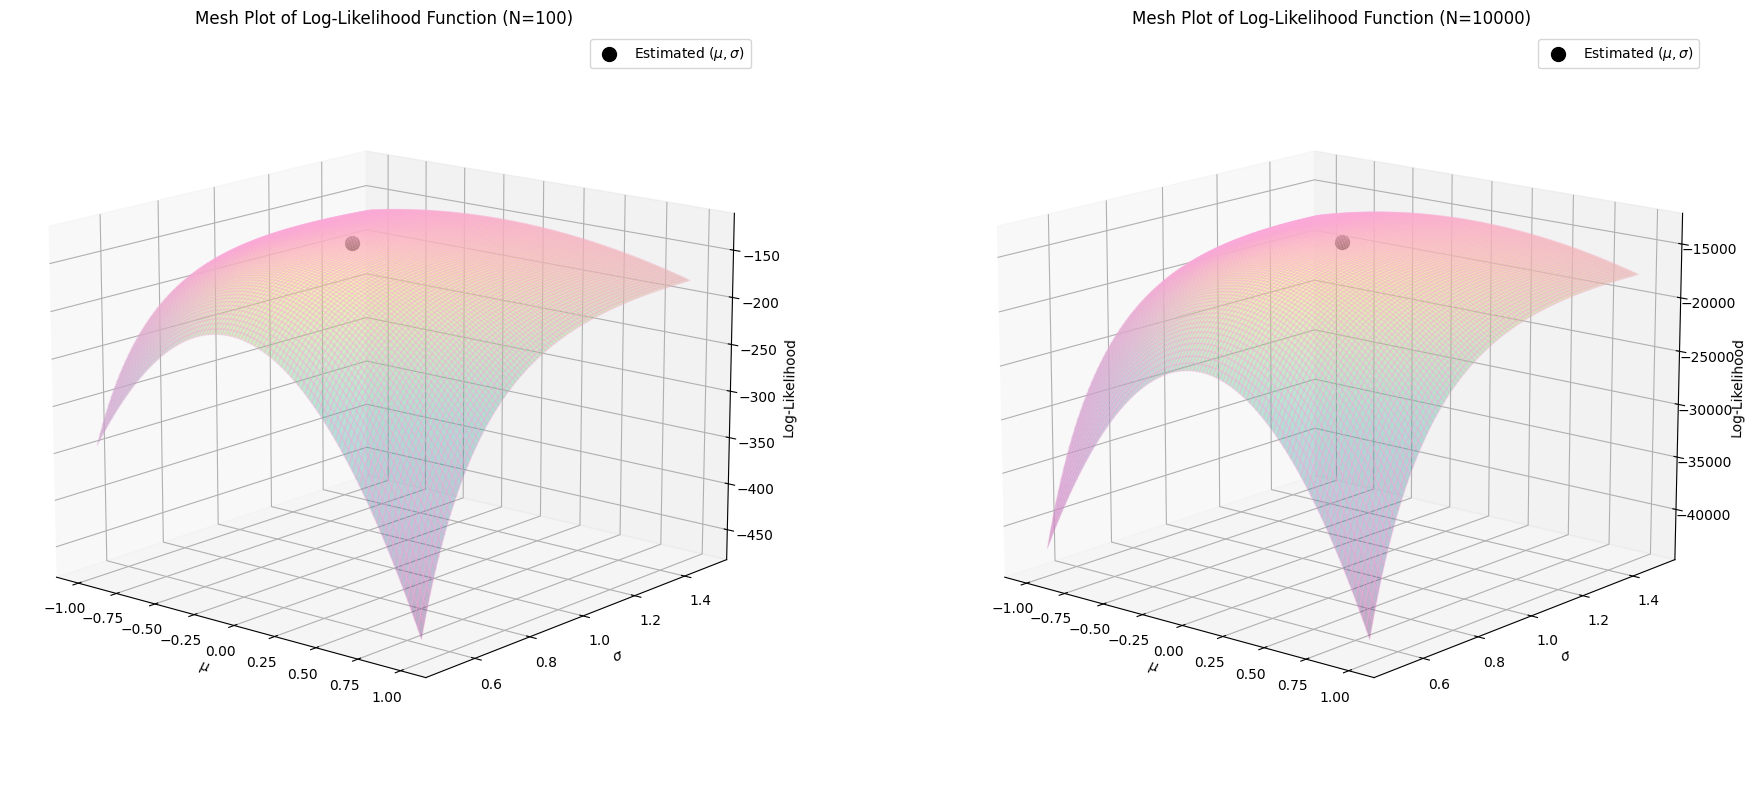

In [25]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# 定義聯合對數概似函數
def log_likelihood(mu, sigma, samples):
    if sigma <= 0:  # 確保標準差為正
        return -np.inf
    return np.sum(np.log(stats.norm.pdf(samples, loc=mu, scale=sigma)))

# 定義負對數概似函數
def neg_log_likelihood(params, samples):
    mu, sigma = params
    return -log_likelihood(mu, sigma, samples)

# 設定樣本數
N_values = [100, 10000]
mu_true = 0
sigma_true = 1

# 繪製兩張圖
fig, axs = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': '3d'})  # 調整整張大圖的大小

for i, N in enumerate(N_values):
    # 生成樣本
    samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
    
    # 使用 minimize 進行優化，最小化負的對數聯合概似函數
    initial_guess = [0, 1]
    result = minimize(neg_log_likelihood, initial_guess, args=(samples,))
    mu_est, sigma_est = result.x
    print(f"Estimated μ: {mu_est}, Estimated σ: {sigma_est} for N={N}")

    # 設定 \mu 和 \sigma 的範圍
    mu_range = np.linspace(-1, 1, 100)
    sigma_range = np.linspace(0.5, 1.5, 100)

    # 計算聯合對數概似函數值
    log_likelihood_values = np.zeros((len(sigma_range), len(mu_range)))
    for j, sigma in enumerate(sigma_range):
        for k, mu in enumerate(mu_range):
            log_likelihood_values[j, k] = log_likelihood(mu, sigma, samples)

    # 檢查數值範圍
    print(f"Log-likelihood min: {log_likelihood_values.min()}, max: {log_likelihood_values.max()} for N={N}")

    # 繪製光滑的 3D 表面圖
    X, Y = np.meshgrid(mu_range, sigma_range)
    ax = axs[i]
    surface = ax.plot_surface(X, Y, log_likelihood_values, cmap='viridis', edgecolor='none', alpha=0.3, rstride=1, cstride=1, color='#FFA9E0')

    # 標註最佳估計的 \mu 和 \sigma
    ax.scatter(mu_est, sigma_est, log_likelihood(mu_est, sigma_est, samples), color='black', label='Estimated $(\\mu, \\sigma)$', s=100)
    ax.legend()

    # 設置標題和標籤
    ax.set_title(f'Mesh Plot of Log-Likelihood Function (N={N})')
    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$\sigma$')
    ax.set_zlabel('Log-Likelihood')

    # 設置視角
    ax.view_init(elev=15, azim=310)  # 仰角 15 度，方位角 310 度

plt.tight_layout()
plt.show()

> ##### <font color = '#384772'>__**注意事項與討論：**__ </font>
>
>- 中心黑點為使用最大對數概似估計法（MLE）所得到的最佳估計值 $\mu$, $\sigma$ 位置，對比兩張樣本數不同的圖可發現，樣本數越大，越接近真實值（ $\mu$ =0, $\sigma$ = 1）），且此點的對數聯合函數為最大值。
>- 當樣本數較大時（N=10000），曲面更為陡峭，表示估計值對參數變動更加敏感；當樣本數較少（N=100）時，曲面較為平緩，顯示出估計值的不確定性較大。
>- 在Z軸可以發現，樣本數越大對數聯合函數範圍越大，值也越小。
>- Mesh plot呈現曲面樣式
>- 視角的調整在製圖時尤為重要，因此這邊將仰角調整成15度，方位角310度，使用ax.view_init(elev=15, azim=310)。

Estimated μ: -0.14059139879027932, Estimated σ: 1.0323100131107552 for N=100
Log-likelihood min: -495.90167635533413, max: -145.0742683609291 for N=100
Estimated μ: 0.009247765811926073, Estimated σ: 1.0144848641098674 for N=10000
Log-likelihood min: -43213.12540846139, max: -14333.984535572163 for N=10000


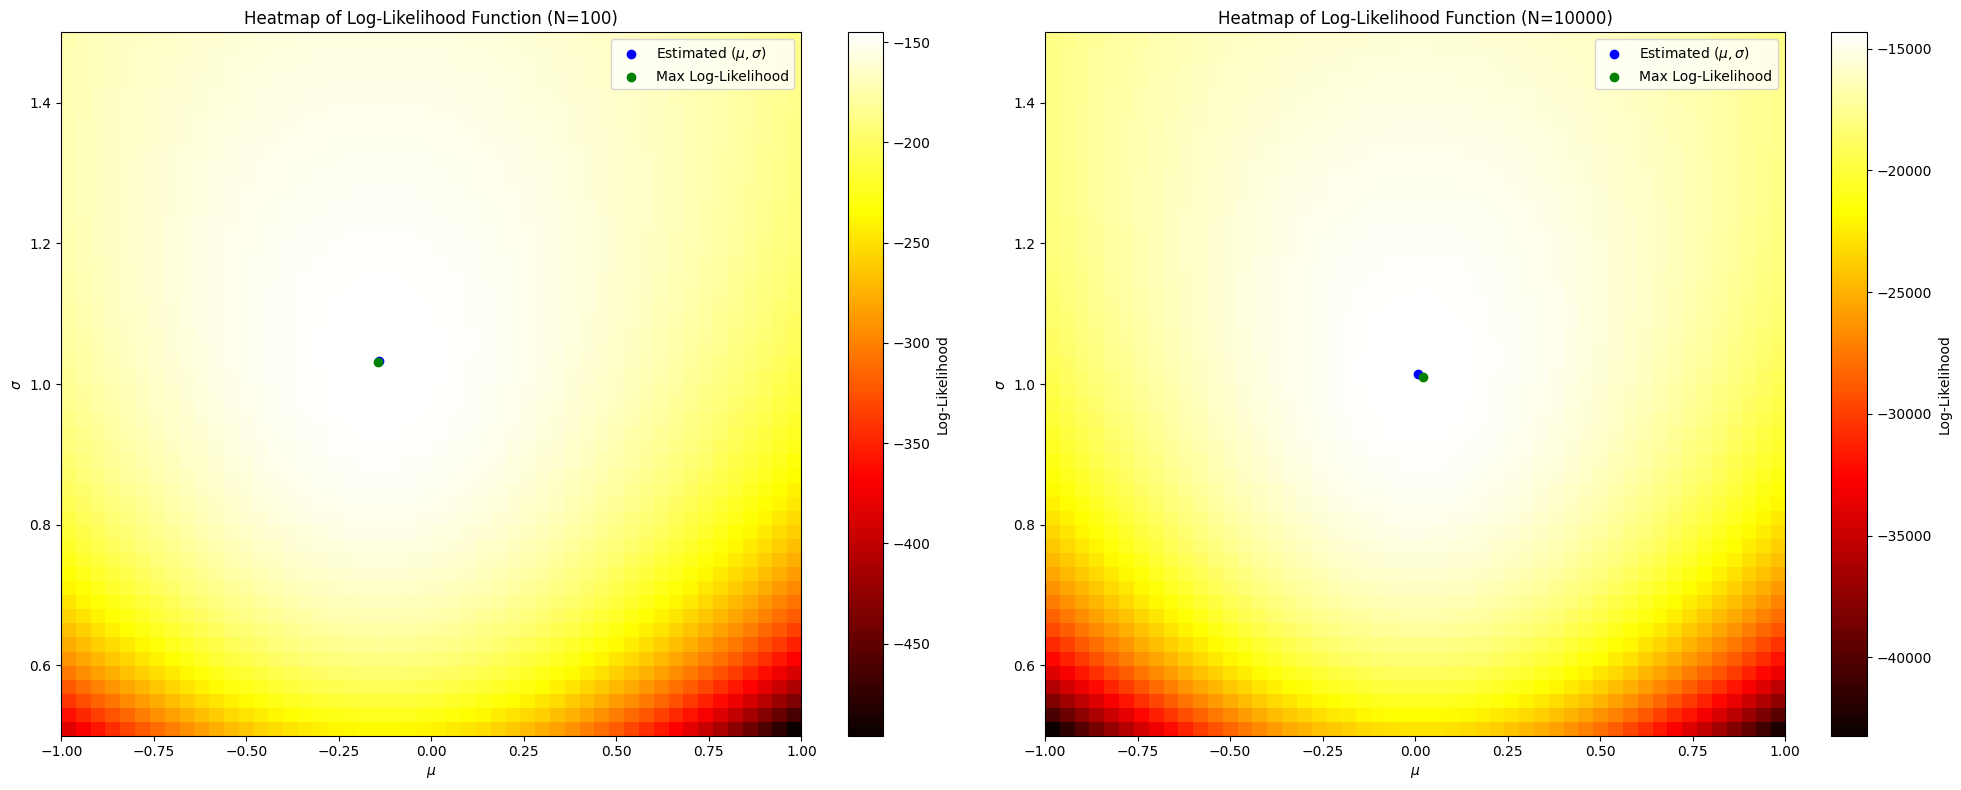

In [29]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 定義聯合對數概似函數
def log_likelihood(mu, sigma, samples):
    if sigma <= 0:  # 確保標準差為正
        return -np.inf
    pdf_values = stats.norm.pdf(samples, loc=mu, scale=sigma)
    if np.any(pdf_values <= 0):  # 確保 PDF 值為正
        return -np.inf
    return np.sum(np.log(pdf_values))

# 定義負對數概似函數
def neg_log_likelihood(params, samples):
    mu, sigma = params
    return -log_likelihood(mu, sigma, samples)

# 設定樣本數
N_values = [100, 10000]
mu_true = 0
sigma_true = 1

# 繪製兩張圖
fig, axs = plt.subplots(1, 2, figsize=(20, 8))  # 調整整張大圖的大小

for i, N in enumerate(N_values):
    # 生成樣本
    samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
    
    # 使用 minimize 進行優化，最小化負的對數聯合概似函數
    initial_guess = [0, 1]
    result = minimize(neg_log_likelihood, initial_guess, args=(samples,))
    mu_est, sigma_est = result.x
    print(f"Estimated μ: {mu_est}, Estimated σ: {sigma_est} for N={N}")

    # 設定 \mu 和 \sigma 的範圍
    mu_range = np.linspace(-1, 1, 50)
    sigma_range = np.linspace(0.5, 1.5, 50)

    # 計算聯合對數概似函數值
    log_likelihood_values = np.zeros((len(sigma_range), len(mu_range)))
    for j, sigma in enumerate(sigma_range):
        for k, mu in enumerate(mu_range):
            log_likelihood_values[j, k] = log_likelihood(mu, sigma, samples)

    # 檢查數值範圍
    print(f"Log-likelihood min: {log_likelihood_values.min()}, max: {log_likelihood_values.max()} for N={N}")

    # 繪製 heatmap
    X, Y = np.meshgrid(mu_range, sigma_range)
    ax = axs[i]
    heatmap = ax.imshow(log_likelihood_values, extent=[-1, 1, 0.5, 1.5], origin='lower', aspect='auto', cmap='hot', interpolation='nearest')
    cbar = plt.colorbar(heatmap, ax=ax)
    cbar.set_label('Log-Likelihood')

    # 標註最佳估計的 \mu 和 \sigma
    ax.scatter(mu_est, sigma_est, color='blue', label='Estimated $(\\mu, \\sigma)$')

    # 標註最大值的位置
    max_idx = np.unravel_index(np.argmax(log_likelihood_values), log_likelihood_values.shape)
    max_mu = mu_range[max_idx[1]]
    max_sigma = sigma_range[max_idx[0]]
    ax.scatter(max_mu, max_sigma, color='green', label='Max Log-Likelihood')

    # 設置標題和標籤
    ax.set_title(f'Heatmap of Log-Likelihood Function (N={N})')
    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$\sigma$')
    ax.legend()

plt.tight_layout()
plt.show()

> ##### <font color = '#384772'>__**注意事項與討論：**__</font>
>
>- 中心藍點為使用最大對數概似估計法（MLE）所得到的最佳估計值 $\mu$, $\sigma$ 位置，對比兩張樣本數不同的圖可發現，樣本數越大，越接近真實值（ $\mu$ =0, $\sigma$ = 1）），且此點的對數聯合函數為最大值。
>- 綠色點標記的是在熱力圖中計算出的最大對數概似值對應的 $\mu$, $\sigma$ 位置，藍色的點和綠色的點應該要很接近，會有分開的狀況可能是因熱力圖有網格解析度的問題導致些微差異。
>- 熱力圖因顏色配置，可以清楚看出淺色區算出對數最大概似函數值較大，這些 $\mu$, $\sigma$ 組合是更好的模型擬合參數。
>- 和前兩張圖相同，可在右側顏色軸上看出樣本數N越大，對數最大概似函數值越小，負數範圍越大。

<hr>
<font color=#EF9520> （四）不同樣本重複生成M次觀察單變量估計值之折線圖</font>  

1. 給定樣本數N=10, 50, 100, 500, 1000, 10000，分別重複生成樣本M次（M=100），並記錄每次估計值，做完100次後，每個N樣本取平均並繪製兩張折線圖分別觀察 $\mu$, $\sigma$ 之估計值。
2. 給定樣本數N=10, 50, 100, 500, 1000, 10000，分別重複生成樣本M次（M=1000），並記錄每次估計值，做完1000次後，每個N樣本取平均並繪製兩張折線圖分別觀察 $\mu$, $\sigma$ 之估計值。

__**（紅色虛線標示為真實值）**__

<hr>

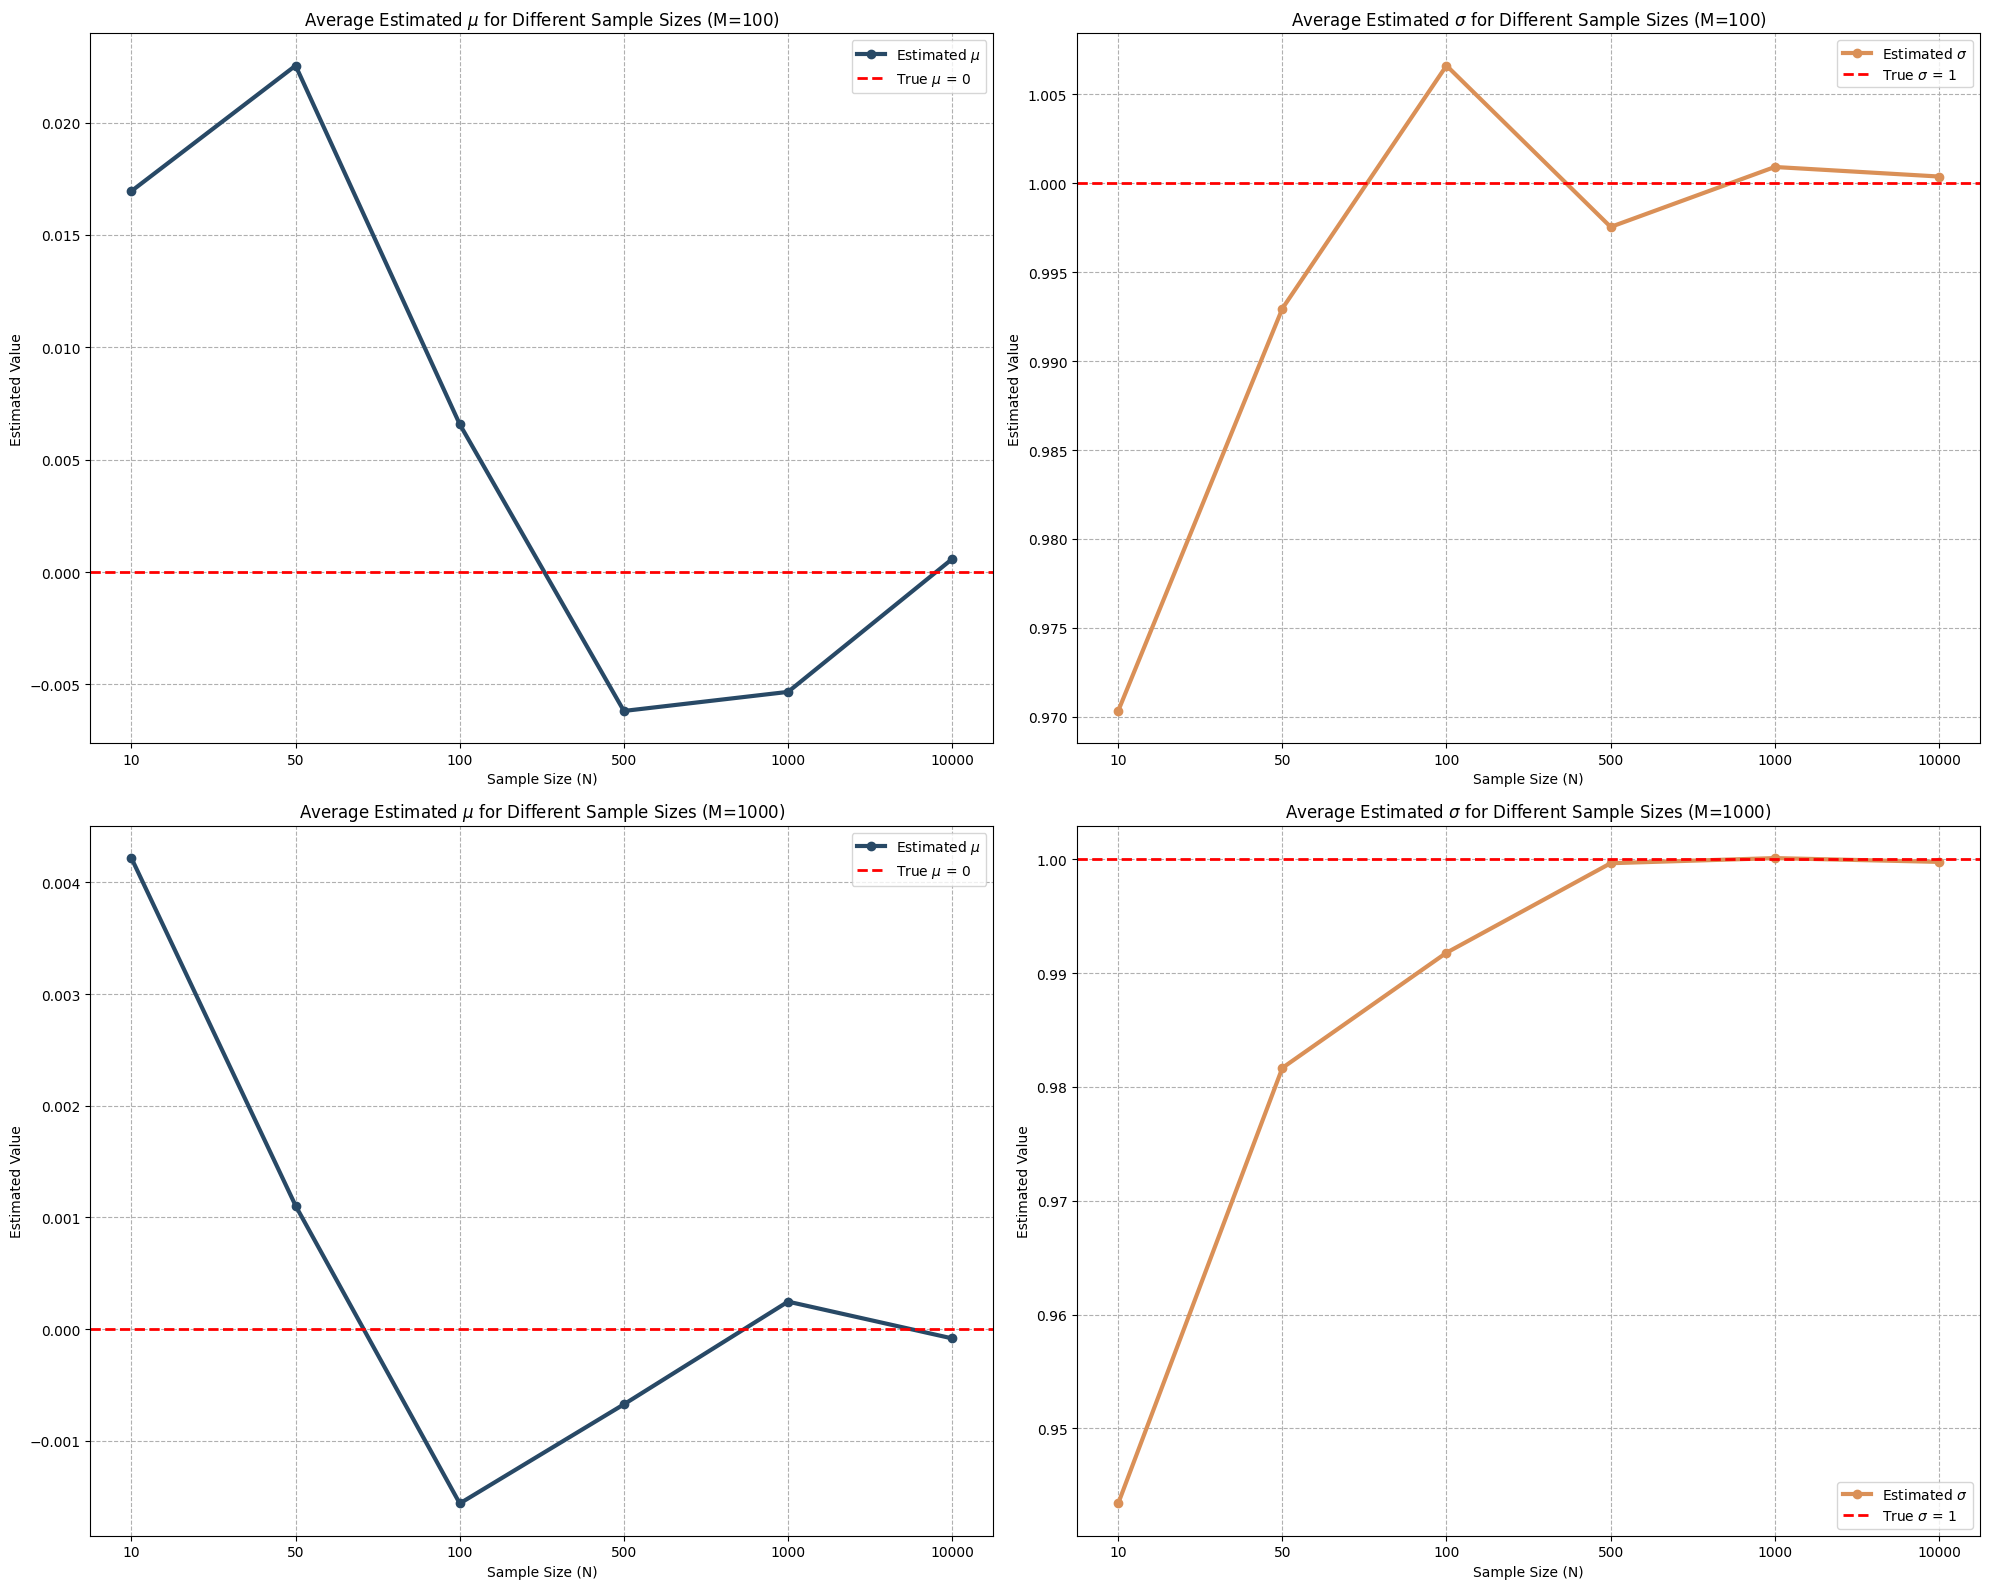

In [34]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 定義聯合對數概似函數
def log_likelihood(mu, sigma, samples):
    if sigma <= 0:  # 確保標準差為正
        return -np.inf
    pdf_values = stats.norm.pdf(samples, loc=mu, scale=sigma)
    if np.any(pdf_values <= 0):  # 確保 PDF 值為正
        return -np.inf
    return np.sum(np.log(pdf_values))

# 定義負聯合對數概似函數
def neg_log_likelihood(params, samples):
    mu, sigma = params
    return -log_likelihood(mu, sigma, samples)

# 設定不同的樣本數
N_values = [10, 50, 100, 500, 1000, 10000]
M = 100
M_large = 1000
mu_true = 0
sigma_true = 1

# 儲存每次生成的最佳估計值的平均值
mu_estimates_avg = []
sigma_estimates_avg = []
mu_estimates_avg_large = []
sigma_estimates_avg_large = []

for N in N_values:
    mu_estimates = []
    sigma_estimates = []
    
    for _ in range(M):
        # 生成樣本
        samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
        
        # 使用 minimize 進行優化，最小化負的聯合對數概似函數
        initial_guess = [0, 1]
        result = minimize(neg_log_likelihood, initial_guess, args=(samples,), method='L-BFGS-B', bounds=[(-np.inf, np.inf), (1e-6, np.inf)])
        if result.success:
            mu_est, sigma_est = result.x
            mu_estimates.append(mu_est)
            sigma_estimates.append(sigma_est)
    
    # 計算每個樣本數 N 下的平均最佳估計值
    mu_estimates_avg.append(np.mean(mu_estimates))
    sigma_estimates_avg.append(np.mean(sigma_estimates))

for N in N_values:
    mu_estimates_large = []
    sigma_estimates_large = []
    
    for _ in range(M_large):
        # 生成樣本
        samples = stats.norm.rvs(loc=mu_true, scale=sigma_true, size=N)
        
        # 使用 minimize 進行優化，最小化負的聯合對數概似函數
        initial_guess = [0, 1]
        result = minimize(neg_log_likelihood, initial_guess, args=(samples,), method='L-BFGS-B', bounds=[(-np.inf, np.inf), (1e-6, np.inf)])
        if result.success:
            mu_est, sigma_est = result.x
            mu_estimates_large.append(mu_est)
            sigma_estimates_large.append(sigma_est)
    
    # 計算每個樣本數 N 下的平均最佳估計值
    mu_estimates_avg_large.append(np.mean(mu_estimates_large))
    sigma_estimates_avg_large.append(np.mean(sigma_estimates_large))

# 繪製折線圖
fig, axs = plt.subplots(2, 2, figsize=(20, 16))  # 調整圖的大小

# 繪製 \(\mu\) 的折線圖 (M = 100)
axs[0, 0].plot(range(len(N_values)), mu_estimates_avg, marker='o', label=r'Estimated $\mu$', color='#284966', linewidth=3)  
axs[0, 0].set_xticks(range(len(N_values)))
axs[0, 0].set_xticklabels([str(N) for N in N_values])  # 設置 x 軸的點數值
axs[0, 0].axhline(0, color='red', linestyle='--', label=r'True $\mu$ = 0', linewidth=2)  # 在 y 軸的 0 處畫一條紅色虛線
axs[0, 0].set_xlabel('Sample Size (N)')
axs[0, 0].set_ylabel('Estimated Value')
axs[0, 0].set_title(r'Average Estimated $\mu$ for Different Sample Sizes (M=100)')
axs[0, 0].legend()
axs[0, 0].grid(True, which="both", ls="--")

# 繪製 \(\sigma\) 的折線圖 (M = 100)
axs[0, 1].plot(range(len(N_values)), sigma_estimates_avg, marker='o', label=r'Estimated $\sigma$', color='#DA9057', linewidth=3)
axs[0, 1].set_xticks(range(len(N_values)))
axs[0, 1].set_xticklabels([str(N) for N in N_values])  # 設置 x 軸的點數值
axs[0, 1].axhline(sigma_true, color='red', linestyle='--', label=r'True $\sigma$ = 1', linewidth=2)  # 在 y 軸的 1 處畫一條紅色虛線
axs[0, 1].set_xlabel('Sample Size (N)')
axs[0, 1].set_ylabel('Estimated Value')
axs[0, 1].set_title(r'Average Estimated $\sigma$ for Different Sample Sizes (M=100)')
axs[0, 1].legend()
axs[0, 1].grid(True, which="both", ls="--")

# 繪製 \(\mu\) 的折線圖 (M = 1000)
axs[1, 0].plot(range(len(N_values)), mu_estimates_avg_large, marker='o', label=r'Estimated $\mu$', color='#284966', linewidth=3)  
axs[1, 0].set_xticks(range(len(N_values)))
axs[1, 0].set_xticklabels([str(N) for N in N_values])  # 設置 x 軸的點數值
axs[1, 0].axhline(0, color='red', linestyle='--', label=r'True $\mu$ = 0', linewidth=2)  # 在 y 軸的 0 處畫一條紅色虛線
axs[1, 0].set_xlabel('Sample Size (N)')
axs[1, 0].set_ylabel('Estimated Value')
axs[1, 0].set_title(r'Average Estimated $\mu$ for Different Sample Sizes (M=1000)')
axs[1, 0].legend()
axs[1, 0].grid(True, which="both", ls="--")

# 繪製 \(\sigma\) 的折線圖 (M = 1000)
axs[1, 1].plot(range(len(N_values)), sigma_estimates_avg_large, marker='o', label=r'Estimated $\sigma$', color='#DA9057', linewidth=3)
axs[1, 1].set_xticks(range(len(N_values)))
axs[1, 1].set_xticklabels([str(N) for N in N_values])  # 設置 x 軸的點數值
axs[1, 1].axhline(sigma_true, color='red', linestyle='--', label=r'True $\sigma$ = 1', linewidth=2)  # 在 y 軸的 1 處畫一條紅色虛線
axs[1, 1].set_xlabel('Sample Size (N)')
axs[1, 1].set_ylabel('Estimated Value')
axs[1, 1].set_title(r'Average Estimated $\sigma$ for Different Sample Sizes (M=1000)')
axs[1, 1].legend()
axs[1, 1].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

> ##### <font color = '#384772'>__**注意事項與討論：**__ </font>
>
>- 此程式在運行時比前幾個程式運行速度緩慢許多，係因進行多次迴圈，因此最終只進行M=100, M=1000的實現。
>- 對 $\mu$ 的估計：
>
> (1)當樣本數較少（如 N=10, 50）時，對 $\mu$ 的的估計波動較大，與真實值 $\mu$ = 0 偏差較明顯，與實驗（三）得出之結果相同。
>
> (2)樣本數越大，M次數越大，估計值越接近真實值，可觀察到當N=10000, M=1000時估計值幾乎等於真實值。
>
>- 對 $\sigma$ 的估計：
>
> (1)同樣，當樣本數較少（如 N=10, 50）時，對 $\sigma$ 的的估計波動較大，與真實值 $\sigma$ = 1 偏差較明顯，與實驗（三）得出之結果相同。
>
> (2)隨著樣本數的增加，估計值逐漸接近真實的 $\sigma$ = 1，當M=100, 1000時，N超過1000都幾乎接近真實值。
>- 對 $\mu$, $\sigma$ 的估計比較：
> (1)波動性：仔細觀察會發現 $\mu$, $\sigma$ 圖型的y軸間隔並不相同， $\mu$ 的間隔較 $\sigma$ 小，因此可發現通常對 $\mu$ 的估計結果比對 $\sigma$ 的估計結果要更穩定，尤其在樣本數較小的情況下。
>
> (2)收斂速度：對 $\mu$ 估計通常會比對 $\sigma$ 的估計更快收斂，這意味著隨著樣本數增加，對 $\mu$ 的估計會更早趨近於真實值。
>
> (3) $\mu$ 的估計對樣本變化量較不敏感，在做 $\sigma$ 估計時，當樣本數量較小時，個別極端值會對標準差估計產生較大影響，因此標準差估計的波動會更大，因此，在相同的M下，對 $\mu$ 的估計通常比對 $\sigma$ 的估計更穩定且收斂更快。
>
>- M=1000的情況比M=100的波動性小，這是因為隨著重複實驗次數 M 的增加，估計值的方差減小，使得平均值更穩定。